In [2]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns

Before beginning exploratory data analysis (EDA), analysts should first understand variable types (nominal, ordinal, interval, ratio) and basic descriptive statistics (measures of central tendency, dispersion, and frequency distributions). This theoretical knowledge together with domain knowledge guides the choice of visualizations, summary statistics, and preprocessing steps during practical EDA.

Variable Types and Looking at Data

1.1 Variable Types 
Variables are things that can change (or vary). A variable that we think is a cause is referred to as an independent variable. In machine learning projects these variables are sometimes referred to as predictor variables. Dependent variables are variables whose behaviour is influenced by the independent variables. We think of these variables as effect variables or outcome variables. 

On a broader scale, variables can be classified as categorical or continuous and within these types, there exists different levels of measurement. 

Categorical variables are variables which can take on two or more different discrete values or categories. In the event that the variable can only take on two distinct types, we refer to this variable as a binary variable. When there are more than two possibilities, the variable is said to be a nominal variable. When categories are ordered, the variable is said to be ordinal. Only a hand full of arithmetic techniques can be applied to categorical variables for example measures of heterogeneity such as the gini index or entropy measurement are some popular analytic techniques. Continuous variables on the other hand, can be analysed using a lot more mathematical techniques they can take on any value on the selected measurement scale. Continuous variables which are measured on an interval scale are called interval variables. Similarly, continuous variables measured on ratio scale are called ratio variables 

When working with datasets (large or small), the different values that our variables can take on is our data. The EDA process aims to identify patterns within this data. This process begins with a data exploration phase where different charactersitics of the data are extracted or investigated. This exploration is critical as it reveals the fundamental structure of your data and helps prompt deeper and targeted investigation.

Investigating the characteristics of the data can take on various forms and mean anything from extracting the descriptive statistics, investigating the sample size and data dimensionality or assessing the data quality.  

1.2 Descriptive Statistics

Descriptive statistics give a summary of a dataset. The information drawn from descriptive statistics should not be used to make predictions or draw conclusions but should be used to gain an understanding of the information at a glance. 

Measures of central tendency:
Give an indication of where the centre of a frequency distribution lies.

Mode: The score that occurs the most. Can be easily identified and visualised in small datasets. Does not reveal much information if the data is bimodal or multimodal. 

Median: The centre score when scores are ranked in order of magnitude. Is relatively unaffected by outliers (extreme scores at either end of the distribution) and the skewness of the data.

Mean: The average score. Can be influenced by outliers and skewed distributions. 

Measures of dispersion:
These metrics quantify the spread of the data

Range: The smallest score subtracted from the largest score. Sensitive to outliers.

Interquartile range: The range of the middle 50% of the scores. Is less sensitive to extreme observations.
    
Variance: The spread of data points around the variable mean in a dataset

Standard Deviation: Also measures the spread of data points around the variable mean in the dataset. Is the square root of the variance

1.3 Frequency Distributions 
A frequency distribution is a graph of how many times each score occurs. 

Frequency distributions can take on different shapes. A normal distribution occurs when scores a re centred around the mean and is characterised by the bell-shaped curve. There are two main ways in which a distribution can deviate from normal; skewness and kurtosis.
    
A skewed distribution occurs when the most frequent scores are clustered at one end of the measurement scale. Skewed distributions can be positively or negatively skewed where positively skewed have a higher frequency of scores clustered at the lower end of the scale and negatively skewed distributions have a higher frequency of scores clustered at the higher end of the scale.

Kurtosis is the degree to which scores cluster at the ends of the distribution or how pointy the distribution is. A distribution with positive kurtosis has a sharp peak and heavier tails then the normal distribution. This type of distribution is called leptokurtic. A distribution with a negative kurtosis is called platykurtic and is characaterised by a flatter/broader peaks and has lighter tails.



EDA workflow:
1. Load data 
2. Inspect structure 
3. Check datatypes 
4. Check missing values 
5. Check duplicates
6. Explore distributions
7. Analyze categorical variables 
8. Analyze numerical variables 
9. Explore relationships 
10. Perform grouped analysis 
11. Generate visualisations
12. Summarise findings 

 This notebook will explore the non-clean version of DataScientist.csv.

In python, we can get a brief understanding of our variables by inspecting the first few entries of the dataframe.

In [12]:
df = pd.read_csv('../data/raw/DataScientist.csv')
df.head()

,Unnamed: 0,index,Job Title,Salary Estimate,Job Description,Rating,Company Name,Location,Headquarters,Size,Founded,Type of ownership,Industry,Sector,Revenue,Competitors,Easy Apply
0,0,0,Senior Data Scientist,$111K-$181K (Glassdoor est.),"ABOUT HOPPER\n\nAt Hopper, we’re on a mission ...",3.5,Hopper\n3.5,"New York, NY","Montreal, Canada",501 to 1000 employees,2007,Company - Private,Travel Agencies,Travel & Tourism,Unknown / Non-Applicable,-1,-1
1,1,1,"Data Scientist, Product Analytics",$111K-$181K (Glassdoor est.),"At Noom, we use scientifically proven methods ...",4.5,Noom US\n4.5,"New York, NY","New York, NY",1001 to 5000 employees,2008,Company - Private,"Health, Beauty, & Fitness",Consumer Services,Unknown / Non-Applicable,-1,-1
2,2,2,Data Science Manager,$111K-$181K (Glassdoor est.),Decode_M\n\nhttps://www.decode-m.com/\n\nData ...,-1.0,Decode_M,"New York, NY","New York, NY",1 to 50 employees,-1,Unknown,-1,-1,Unknown / Non-Applicable,-1,True
3,3,3,Data Analyst,$111K-$181K (Glassdoor est.),Sapphire Digital seeks a dynamic and driven mi...,3.4,Sapphire Digital\n3.4,"Lyndhurst, NJ","Lyndhurst, NJ",201 to 500 employees,2019,Company - Private,Internet,Information Technology,Unknown / Non-Applicable,"Zocdoc, Healthgrades",-1
4,4,4,"Director, Data Science",$111K-$181K (Glassdoor est.),"Director, Data Science - (200537)\nDescription...",3.4,United Entertainment Group\n3.4,"New York, NY","New York, NY",51 to 200 employees,2007,Company - Private,Advertising & Marketing,Business Services,Unknown / Non-Applicable,"BBDO, Grey Group, Droga5",-1


We can get more information on the size of the data frame, 

In [13]:
df.shape

(3909, 17)

Get more information on the datatypes, and missing values within the dataset

In [16]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3909 entries, 0 to 3908
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         3909 non-null   int64  
 1   index              3909 non-null   int64  
 2   Job Title          3909 non-null   str    
 3   Salary Estimate    3909 non-null   str    
 4   Job Description    3909 non-null   str    
 5   Rating             3909 non-null   float64
 6   Company Name       3909 non-null   str    
 7   Location           3909 non-null   str    
 8   Headquarters       3909 non-null   str    
 9   Size               3909 non-null   str    
 10  Founded            3909 non-null   int64  
 11  Type of ownership  3909 non-null   str    
 12  Industry           3909 non-null   str    
 13  Sector             3909 non-null   str    
 14  Revenue            3909 non-null   str    
 15  Competitors        3909 non-null   str    
 16  Easy Apply         3909 non-null   

Get some descirptive statistics of the data, 

In [15]:
df.describe()

,Unnamed: 0,index,Rating,Founded
count,3909.000000,3909.000000,3909.000000,3909.000000
mean,1954.000000,2167.446662,3.283576,1479.154771
std,1128.575429,1247.657849,1.575749,855.750138
min,0.000000,0.000000,-1.000000,-1.000000
25%,977.000000,1121.000000,3.200000,1625.000000
50%,1954.000000,2161.000000,3.700000,1976.000000
75%,2931.000000,3249.000000,4.100000,2002.000000
max,3908.000000,4379.000000,5.000000,2020.000000


Although the ".info()" function will return the count of missing values for each variable or colunm, missing values can also be determined using,

In [18]:
df.isnull().sum()

Unnamed: 0           0
index                0
Job Title            0
Salary Estimate      0
Job Description      0
Rating               0
Company Name         0
Location             0
Headquarters         0
Size                 0
Founded              0
Type of ownership    0
Industry             0
Sector               0
Revenue              0
Competitors          0
Easy Apply           0
dtype: int64

Duplicate values can be investigated using,

In [19]:
df.duplicated().sum()

np.int64(0)

Categorical variables can be analysed using the ".unique()" function

In [23]:
from pandas.api.types import is_string_dtype

columns = df.columns.tolist()

for column in columns:
    if is_string_dtype(df[column]):
        print(f"\n{column}:")
        print(df[column].unique())
    


Job Title:
<StringArray>
[                                              'Senior Data Scientist',
                                   'Data Scientist, Product Analytics',
                                                'Data Science Manager',
                                                        'Data Analyst',
                                              'Director, Data Science',
                                                      'Data Scientist',
                                             'Quantitative Researcher',
                                     'Quantitative Research Associate',
                                                        'AI Scientist',
                                     'Data Scientist/Machine Learning',
 ...
                                                     'Sr Data Modeler',
                    'Biotransformation Scientist and DMPK Design Lead',
 'JPSC-7975 - Data Analyst Lead- Columbus, OH (LOCAL CANDIDATES ONLY)',
               'Senior/Principal 

For smaller datasets visualations can be helpful in understanding how variables are distributed. Visualisations can help identify skewness, spread and outliers.

Note: The bin number selected has an impact on how the frequency distribution plot/histogram looks.

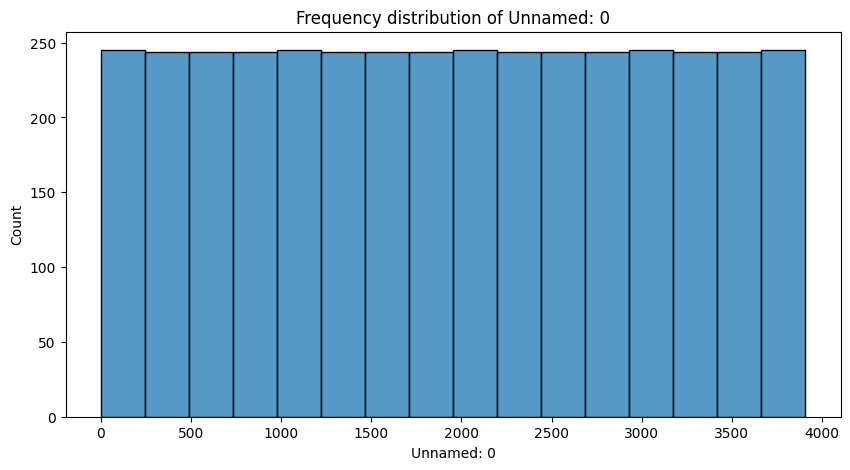

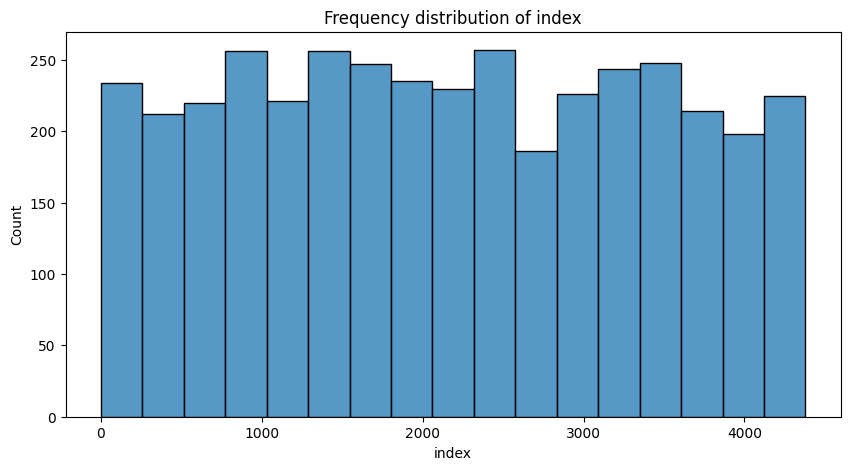

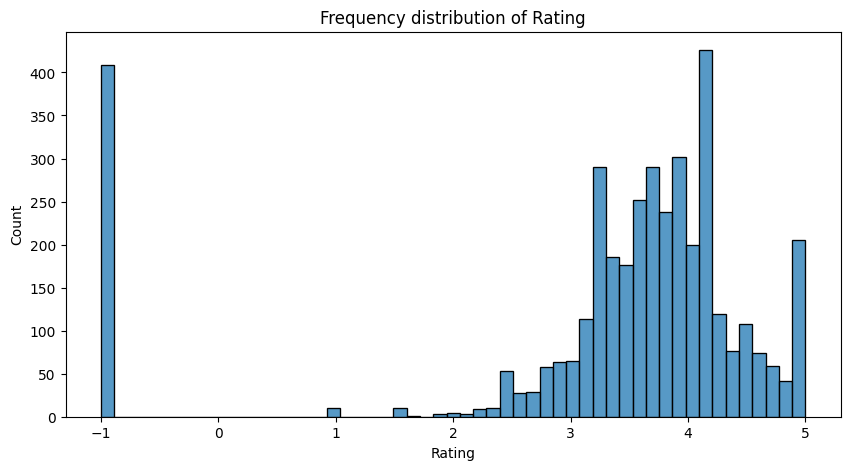

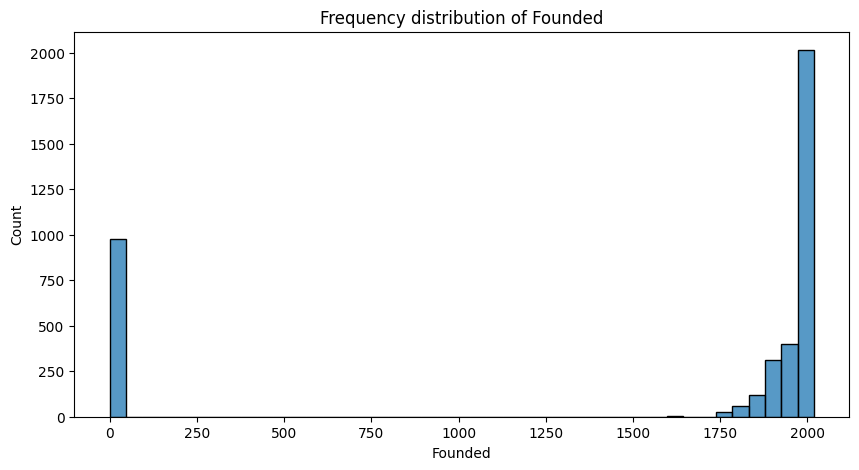

In [28]:
from pandas.api.types import is_numeric_dtype

for column in columns:
    if is_numeric_dtype(df[column]):
        plt.figure(f"{column}", figsize=(10,5))
        sns.histplot(df[column])  
        plt.title(f"Frequency distribution of {column}")
        plt.show()

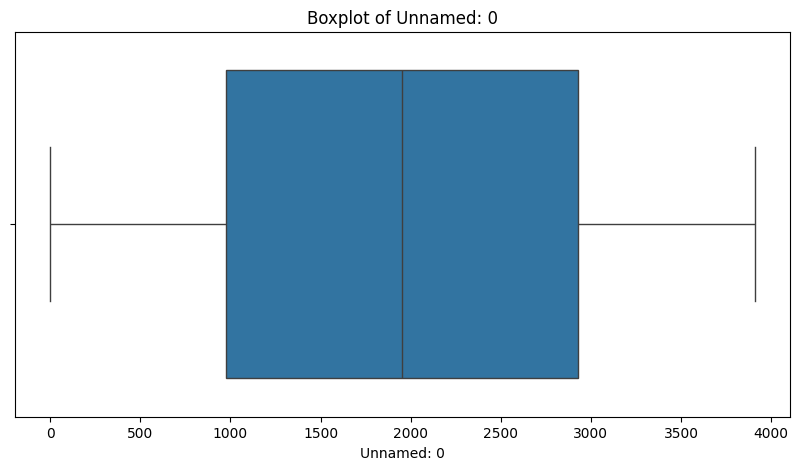

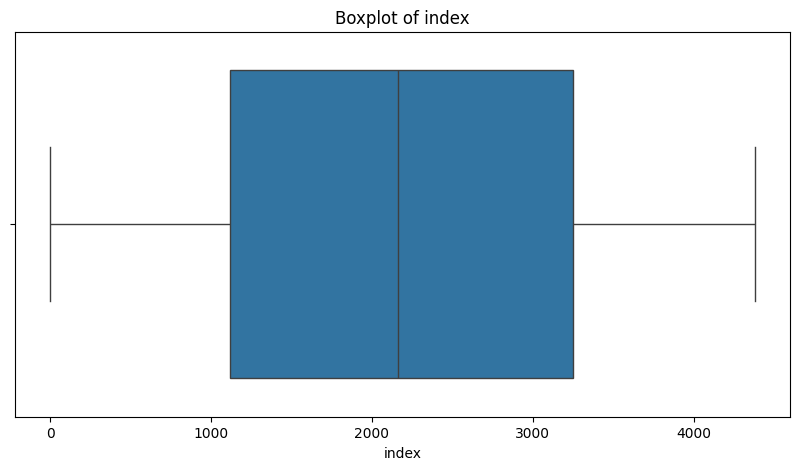

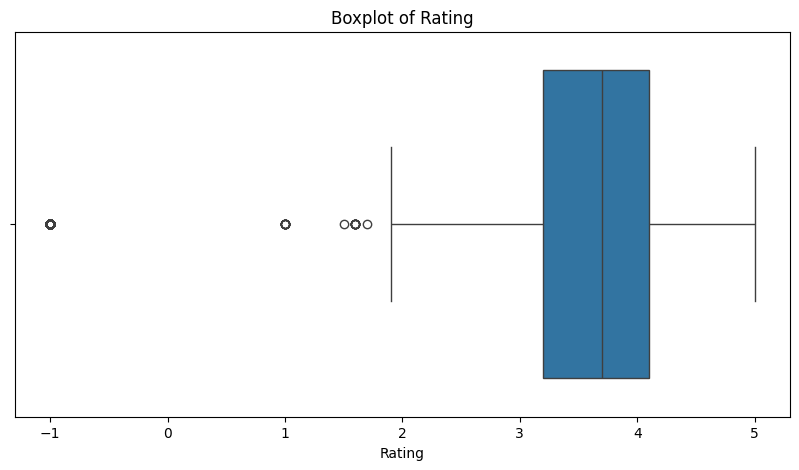

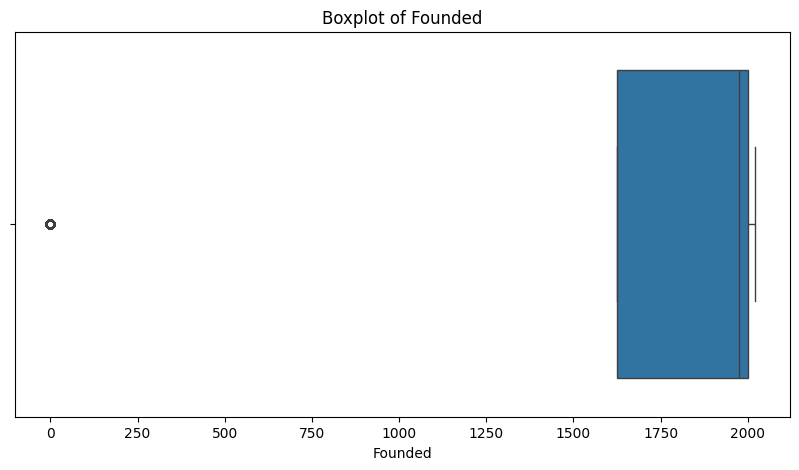

In [29]:
for column in columns:
    if is_numeric_dtype(df[column]):
        plt.figure(f"{column}", figsize=(10,5))
        sns.boxplot(x = df[column])  
        plt.title(f"Boxplot of {column}")
        plt.show()

The correlation between numeric variables can be determined quantitatively in a matrix but can also be visualised using heatmaps.

In [30]:
df.corr(numeric_only=True)

,Unnamed: 0,index,Rating,Founded
Unnamed: 0,1.000000,0.999815,0.041409,-0.012713
index,0.999815,1.000000,0.041706,-0.011974
Rating,0.041409,0.041706,1.000000,0.501881
Founded,-0.012713,-0.011974,0.501881,1.000000


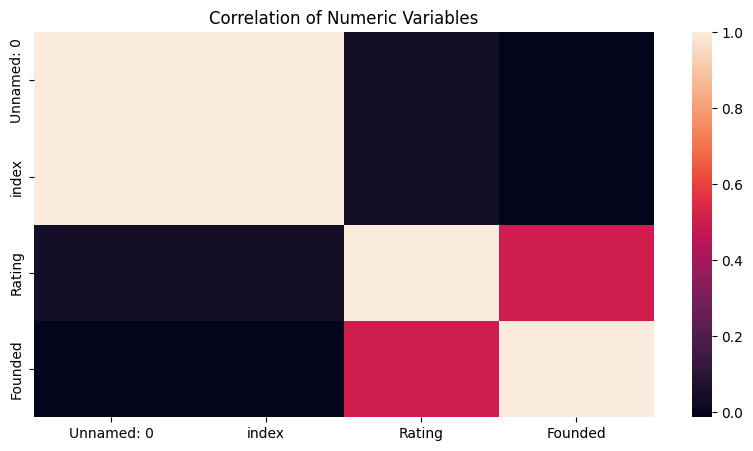

In [32]:
plt.figure("heatmap", figsize=(10,5))
sns.heatmap(df.corr(numeric_only=True))
plt.title("Correlation of Numeric Variables")
plt.show()

One can also perform grouped analysis and generate more interesting visualisations to start gaining some insights however this type of analysis may be more useful once the dataset has been cleaned.